# 🎧 Audio Language Model (ALM) — Dataset Preprocessing Pipeline

This notebook preprocesses **ESC-50** and **UrbanSound8K** datasets into a unified, standardized format for transformer-based audio model training.

### Pipeline Summary
| Step | Operation |
|------|----------|
| 1 | Convert to `.wav` |
| 2 | Convert to Mono |
| 3 | Resample to 24,000 Hz |
| 4 | Trim / Pad to 5 seconds |
| 5 | Normalize amplitude to `[-1, 1]` |
| 6 | Save with unified naming `alm_XXXXXX.wav` |
| 7 | Update `metadata.csv` |

In [8]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
from pathlib import Path
from tqdm import tqdm

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


## 1. Configuration

In [2]:
# ─── PATH CONFIGURATION ───────────────────────────────────────────────────────
# Update these paths to match your local setup
BASE_DIR        = Path(r"C:/Users/PRAYAG/OneDrive/Desktop/ALM/alm")

RAW_ESC50_DIR   = BASE_DIR / "data" / "raw" / "esc50"         # ESC-50 root folder
RAW_URBAN_DIR   = BASE_DIR / "data" / "raw" / "urbansound8k"  # UrbanSound8K root folder

PROCESSED_DIR   = BASE_DIR / "data" / "processed"
AUDIO_OUT_DIR   = PROCESSED_DIR / "audio"
METADATA_PATH   = PROCESSED_DIR / "metadata.csv"

# ─── AUDIO STANDARDIZATION PARAMETERS ────────────────────────────────────────
TARGET_SR       = 24_000   # 24 kHz
TARGET_DURATION = 5.0      # seconds
TARGET_SAMPLES  = int(TARGET_SR * TARGET_DURATION)  # 120,000 samples
N_FOLDS         = 10

# ─── ESC-50 INTERNAL PATHS ────────────────────────────────────────────────────
# ESC-50 structure: audio/ folder + meta/esc50.csv
ESC50_AUDIO_DIR = RAW_ESC50_DIR / "audio"
ESC50_META_CSV  = RAW_ESC50_DIR / "meta" / "esc50.csv"

# ─── URBANSOUND8K INTERNAL PATHS ─────────────────────────────────────────────
# UrbanSound8K structure: audio/fold1..fold10/ + metadata/UrbanSound8K.csv
URBAN_AUDIO_DIR = RAW_URBAN_DIR / "audio"
URBAN_META_CSV  = RAW_URBAN_DIR / "metadata" / "UrbanSound8K.csv"

print(f'Target SR       : {TARGET_SR} Hz')
print(f'Target Duration : {TARGET_DURATION} s  ({TARGET_SAMPLES} samples)')
print(f'Output dir      : {AUDIO_OUT_DIR}')
print(f'Metadata path   : {METADATA_PATH}')

Target SR       : 24000 Hz
Target Duration : 5.0 s  (120000 samples)
Output dir      : C:\Users\PRAYAG\OneDrive\Desktop\ALM\alm\data\processed\audio
Metadata path   : C:\Users\PRAYAG\OneDrive\Desktop\ALM\alm\data\processed\metadata.csv


## 2. Create Directory Structure

In [3]:
def create_directory_structure():
    """
    Creates the full ALM_Project directory layout.
    Raw data directories are created but left empty (user places raw data there).
    """
    dirs = [
        RAW_ESC50_DIR,
        RAW_URBAN_DIR,
        AUDIO_OUT_DIR,
        PROCESSED_DIR,
    ]
    for d in dirs:
        d.mkdir(parents=True, exist_ok=True)
        print(f'  📁  {d}')
    print('\n✅ Directory structure ready.')

create_directory_structure()

  📁  C:\Users\PRAYAG\OneDrive\Desktop\ALM\alm\data\raw\esc50
  📁  C:\Users\PRAYAG\OneDrive\Desktop\ALM\alm\data\raw\urbansound8k
  📁  C:\Users\PRAYAG\OneDrive\Desktop\ALM\alm\data\processed\audio
  📁  C:\Users\PRAYAG\OneDrive\Desktop\ALM\alm\data\processed

✅ Directory structure ready.


## 3. Core Audio Processing Functions

In [4]:
def load_audio(filepath: Path) -> tuple[np.ndarray, int]:
    """
    Load an audio file using librosa.
    Returns (waveform, original_sample_rate).
    """
    waveform, sr = librosa.load(str(filepath), sr=None, mono=False)
    return waveform, sr


def convert_to_mono(waveform: np.ndarray) -> np.ndarray:
    """
    Convert stereo (or multi-channel) waveform to mono by averaging channels.
    Shape: (channels, samples) → (samples,)
    """
    if waveform.ndim > 1:
        waveform = waveform.mean(axis=0)
    return waveform


def resample_audio(waveform: np.ndarray, orig_sr: int, target_sr: int) -> np.ndarray:
    """
    Resample waveform from orig_sr to target_sr using librosa (high-quality resampling).
    """
    if orig_sr == target_sr:
        return waveform
    return librosa.resample(waveform, orig_sr=orig_sr, target_sr=target_sr)


def pad_or_trim(waveform: np.ndarray, target_samples: int) -> np.ndarray:
    """
    Pad with zeros if shorter than target, trim if longer.
    """
    current_len = len(waveform)
    if current_len < target_samples:
        # Zero-pad at the end
        padding = target_samples - current_len
        waveform = np.pad(waveform, (0, padding), mode='constant')
    elif current_len > target_samples:
        # Trim to first target_samples
        waveform = waveform[:target_samples]
    return waveform


def normalize_waveform(waveform: np.ndarray) -> np.ndarray:
    """
    Normalize waveform amplitude to [-1, 1].
    Avoids division by zero for silent clips.
    """
    peak = np.max(np.abs(waveform))
    if peak > 0:
        waveform = waveform / peak
    return waveform


def preprocess_audio(filepath: Path) -> np.ndarray:
    """
    Full preprocessing pipeline for a single audio file.
    Returns standardized waveform ready for saving.
    """
    waveform, sr = load_audio(filepath)          # Step 1: Load
    waveform = convert_to_mono(waveform)          # Step 2: Mono
    waveform = resample_audio(waveform, sr, TARGET_SR)  # Step 3: Resample
    waveform = pad_or_trim(waveform, TARGET_SAMPLES)    # Step 4: Pad/Trim
    waveform = normalize_waveform(waveform)       # Step 5: Normalize
    return waveform


def save_audio(waveform: np.ndarray, out_path: Path):
    """
    Save waveform as a 16-bit PCM WAV file.
    """
    sf.write(str(out_path), waveform, TARGET_SR, subtype='PCM_16')


print('✅ Audio processing functions defined.')

✅ Audio processing functions defined.


## 4. Dataset Loader Functions

Each function returns a list of dicts with keys:
`filepath`, `label`, `dataset`, `source_file`, `fold`

In [5]:
def load_esc50_manifest() -> list[dict]:
    """
    Parse ESC-50 metadata CSV and return sample manifest.

    ESC-50 CSV columns: filename, fold, target, category, esc10, src_file, take
    """
    if not ESC50_META_CSV.exists():
        raise FileNotFoundError(
            f'ESC-50 metadata not found at: {ESC50_META_CSV}\n'
            'Please place the ESC-50 dataset at: ' + str(RAW_ESC50_DIR)
        )

    df = pd.read_csv(ESC50_META_CSV)
    manifest = []
    for _, row in df.iterrows():
        audio_path = ESC50_AUDIO_DIR / row['filename']
        if audio_path.exists():
            manifest.append({
                'filepath'    : audio_path,
                'label'       : row['category'],
                'dataset'     : 'ESC50',
                'source_file' : row['filename'],
                'fold'        : random.randint(1, N_FOLDS),  # random fold assignment
            })
        else:
            print(f'  ⚠️  Missing: {audio_path}')

    print(f'📦 ESC-50   → {len(manifest)} samples found.')
    return manifest


def load_urbansound8k_manifest() -> list[dict]:
    """
    Parse UrbanSound8K metadata CSV and return sample manifest.

    UrbanSound8K CSV columns: slice_file_name, fsID, start, end, salience,
                               fold, classID, class
    """
    if not URBAN_META_CSV.exists():
        raise FileNotFoundError(
            f'UrbanSound8K metadata not found at: {URBAN_META_CSV}\n'
            'Please place the UrbanSound8K dataset at: ' + str(RAW_URBAN_DIR)
        )

    df = pd.read_csv(URBAN_META_CSV)
    manifest = []
    for _, row in df.iterrows():
        # UrbanSound8K audio is organized into fold subdirectories
        audio_path = URBAN_AUDIO_DIR / f"fold{row['fold']}" / row['slice_file_name']
        if audio_path.exists():
            manifest.append({
                'filepath'    : audio_path,
                'label'       : row['class'],
                'dataset'     : 'UrbanSound8K',
                'source_file' : row['slice_file_name'],
                'fold'        : random.randint(1, N_FOLDS),  # re-assign random fold
            })
        else:
            print(f'  ⚠️  Missing: {audio_path}')

    print(f'📦 UrbanSound8K → {len(manifest)} samples found.')
    return manifest


print('✅ Dataset manifest functions defined.')

✅ Dataset manifest functions defined.


## 5. Main Preprocessing Pipeline

In [6]:
def run_preprocessing_pipeline(manifest: list[dict], start_id: int = 1) -> pd.DataFrame:
    """
    Process all samples in manifest and return metadata DataFrame.

    Args:
        manifest   : list of sample dicts from load_*_manifest()
        start_id   : starting sequential ID for alm_XXXXXX.wav naming

    Returns:
        DataFrame with columns: id, file, label, dataset, duration, fold, source_file
    """
    records = []
    errors  = []
    current_id = start_id

    for sample in tqdm(manifest, desc='Processing audio'):
        try:
            # ── Preprocess ──────────────────────────────────────────────────
            waveform = preprocess_audio(sample['filepath'])

            # ── Build output filename ────────────────────────────────────────
            out_filename = f'alm_{current_id:06d}.wav'
            out_path     = AUDIO_OUT_DIR / out_filename

            # ── Save ────────────────────────────────────────────────────────
            save_audio(waveform, out_path)

            # ── Record metadata ──────────────────────────────────────────────
            records.append({
                'id'          : current_id,
                'file'        : out_filename,
                'label'       : sample['label'],
                'dataset'     : sample['dataset'],
                'duration'    : TARGET_DURATION,
                'fold'        : sample['fold'],
                'source_file' : sample['source_file'],
            })
            current_id += 1

        except Exception as e:
            errors.append({'file': str(sample['filepath']), 'error': str(e)})

    if errors:
        print(f'\n⚠️  {len(errors)} files failed to process:')
        for err in errors[:10]:  # show first 10
            print(f"   {err['file']} → {err['error']}")

    metadata_df = pd.DataFrame(records)
    return metadata_df


print('✅ Pipeline function defined.')

✅ Pipeline function defined.


## 6. Run the Full Pipeline

> ⚠️ **Make sure your raw data is placed correctly before running this cell:**
> - `ALM_Project/data/raw/esc50/` → ESC-50 dataset root
> - `ALM_Project/data/raw/urbansound8k/` → UrbanSound8K dataset root

In [9]:
print('=' * 60)
print(' ALM PREPROCESSING PIPELINE')
print('=' * 60)

# ── Step 1: Load manifests ────────────────────────────────────────────────────
print('\n📋 Loading dataset manifests...')
esc50_manifest   = load_esc50_manifest()
urban_manifest   = load_urbansound8k_manifest()

combined_manifest = esc50_manifest + urban_manifest
print(f'\n🔢 Total samples to process: {len(combined_manifest)}')

# ── Step 2: Run preprocessing ─────────────────────────────────────────────────
print('\n🔧 Running preprocessing pipeline...')
metadata_df = run_preprocessing_pipeline(combined_manifest, start_id=1)

# ── Step 3: Save metadata CSV ─────────────────────────────────────────────────
metadata_df.to_csv(METADATA_PATH, index=False)
print(f'\n💾 Metadata saved → {METADATA_PATH}')

# ── Step 4: Summary ───────────────────────────────────────────────────────────
print('\n' + '=' * 60)
print(f'✅ DONE!  {len(metadata_df)} samples processed successfully.')
print(f'   Audio files : {AUDIO_OUT_DIR}')
print(f'   Metadata    : {METADATA_PATH}')
print('=' * 60)

 ALM PREPROCESSING PIPELINE

📋 Loading dataset manifests...
📦 ESC-50   → 2000 samples found.
📦 UrbanSound8K → 8732 samples found.

🔢 Total samples to process: 10732

🔧 Running preprocessing pipeline...


Processing audio: 100%|██████████| 10732/10732 [04:50<00:00, 36.98it/s]



💾 Metadata saved → C:\Users\PRAYAG\OneDrive\Desktop\ALM\alm\data\processed\metadata.csv

✅ DONE!  10732 samples processed successfully.
   Audio files : C:\Users\PRAYAG\OneDrive\Desktop\ALM\alm\data\processed\audio
   Metadata    : C:\Users\PRAYAG\OneDrive\Desktop\ALM\alm\data\processed\metadata.csv


## 7. Verify Output

In [10]:
# ── Load and display metadata ─────────────────────────────────────────────────
df = pd.read_csv(METADATA_PATH)

print(f'Total samples : {len(df)}')
print(f'Columns       : {list(df.columns)}')
print(f'Unique labels : {df["label"].nunique()}')
print(f'Datasets      : {df["dataset"].value_counts().to_dict()}')
print(f'All 5.0s?     : {(df["duration"] == 5.0).all()}')
print()
df.head(10)

Total samples : 10732
Columns       : ['id', 'file', 'label', 'dataset', 'duration', 'fold', 'source_file']
Unique labels : 58
Datasets      : {'UrbanSound8K': 8732, 'ESC50': 2000}
All 5.0s?     : True



,id,file,label,dataset,duration,fold,source_file
0,1,alm_000001.wav,dog,ESC50,5.0,2,1-100032-A-0.wav
1,2,alm_000002.wav,chirping_birds,ESC50,5.0,1,1-100038-A-14.wav
2,3,alm_000003.wav,vacuum_cleaner,ESC50,5.0,5,1-100210-A-36.wav
3,4,alm_000004.wav,vacuum_cleaner,ESC50,5.0,4,1-100210-B-36.wav
4,5,alm_000005.wav,thunderstorm,ESC50,5.0,4,1-101296-A-19.wav
5,6,alm_000006.wav,thunderstorm,ESC50,5.0,3,1-101296-B-19.wav
6,7,alm_000007.wav,door_wood_knock,ESC50,5.0,2,1-101336-A-30.wav
7,8,alm_000008.wav,can_opening,ESC50,5.0,9,1-101404-A-34.wav
8,9,alm_000009.wav,crow,ESC50,5.0,2,1-103298-A-9.wav
9,10,alm_000010.wav,door_wood_knock,ESC50,5.0,10,1-103995-A-30.wav


In [11]:
# ── Fold distribution ─────────────────────────────────────────────────────────
print('Fold distribution:')
print(df.groupby(['dataset', 'fold']).size().unstack(fill_value=0))

Fold distribution:
fold           1    2    3    4    5    6    7    8    9    10
dataset                                                       
ESC50         175  224  192  192  210  202  198  209  202  196
UrbanSound8K  839  891  900  847  844  861  898  913  857  882


In [12]:
# ── Verify a random processed audio file ──────────────────────────────────────
sample_row  = df.sample(1).iloc[0]
sample_path = AUDIO_OUT_DIR / sample_row['file']

waveform, sr = sf.read(str(sample_path))

print(f'File         : {sample_row["file"]}')
print(f'Label        : {sample_row["label"]}')
print(f'Dataset      : {sample_row["dataset"]}')
print(f'Sample rate  : {sr} Hz  (expected: {TARGET_SR})')
print(f'Num samples  : {len(waveform)}  (expected: {TARGET_SAMPLES})')
print(f'Duration     : {len(waveform)/sr:.2f}s  (expected: 5.0s)')
print(f'Amplitude    : [{waveform.min():.4f}, {waveform.max():.4f}]  (expected: ≈[-1, 1])')
print(f'Shape        : {waveform.shape}')

assert sr == TARGET_SR,                 f'SR mismatch: {sr} != {TARGET_SR}'
assert len(waveform) == TARGET_SAMPLES, f'Length mismatch: {len(waveform)} != {TARGET_SAMPLES}'
assert waveform.ndim == 1,              f'Not mono: ndim = {waveform.ndim}'
assert np.abs(waveform).max() <= 1.0,  f'Amplitude out of range'

print('\n✅ All assertions passed — audio file is correctly preprocessed!')

File         : alm_004166.wav
Label        : air_conditioner
Dataset      : UrbanSound8K
Sample rate  : 24000 Hz  (expected: 24000)
Num samples  : 120000  (expected: 120000)
Duration     : 5.00s  (expected: 5.0s)
Amplitude    : [-0.9644, 1.0000]  (expected: ≈[-1, 1])
Shape        : (120000,)

✅ All assertions passed — audio file is correctly preprocessed!


## 8. Dataset Statistics (Post-Processing)

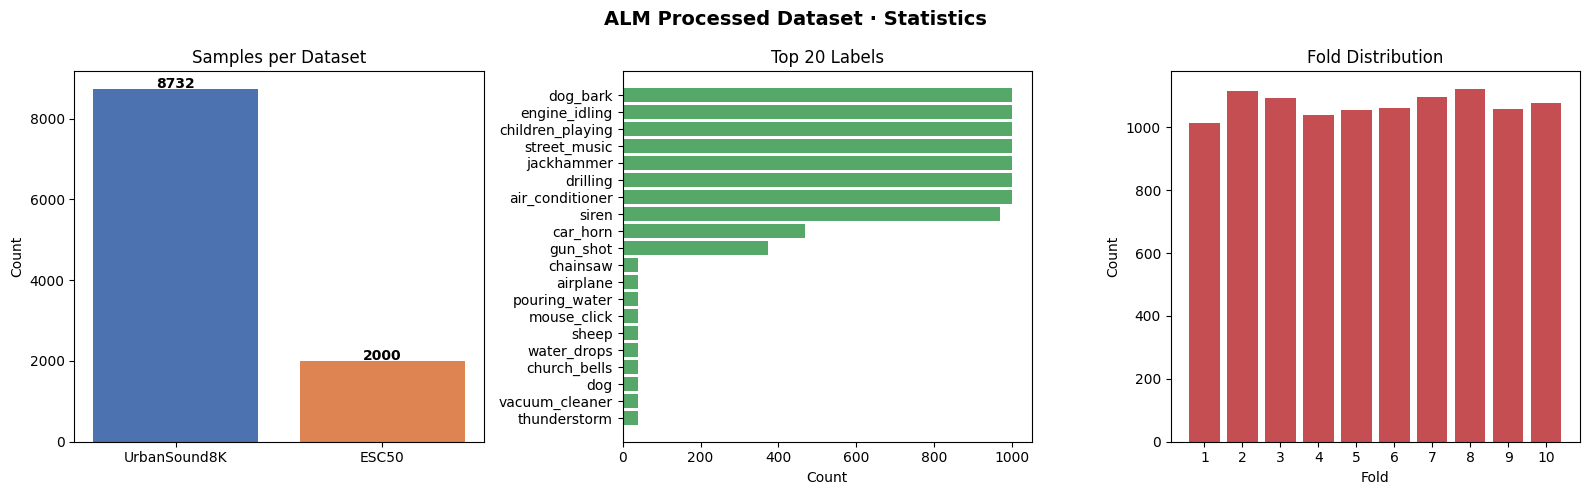

✅ Statistics plot saved.


In [13]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

df = pd.read_csv(METADATA_PATH)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('ALM Processed Dataset · Statistics', fontsize=14, fontweight='bold')

# ── 1. Samples per dataset ────────────────────────────────────────────────────
counts = df['dataset'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Samples per Dataset')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# ── 2. Label distribution (top 20) ───────────────────────────────────────────
top_labels = df['label'].value_counts().head(20)
axes[1].barh(top_labels.index[::-1], top_labels.values[::-1], color='#55A868')
axes[1].set_title('Top 20 Labels')
axes[1].set_xlabel('Count')

# ── 3. Fold distribution ──────────────────────────────────────────────────────
fold_counts = df['fold'].value_counts().sort_index()
axes[2].bar(fold_counts.index, fold_counts.values, color='#C44E52')
axes[2].set_title('Fold Distribution')
axes[2].set_xlabel('Fold')
axes[2].set_ylabel('Count')
axes[2].set_xticks(range(1, N_FOLDS + 1))

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'dataset_statistics.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Statistics plot saved.')

## 9. PyTorch Dataset Class

Ready-to-use `ALMDataset` for use in training scripts.

In [14]:
import torch
from torch.utils.data import Dataset, DataLoader


class ALMDataset(Dataset):
    """
    PyTorch Dataset for the ALM processed audio dataset.

    Args:
        metadata_path : path to metadata.csv
        audio_dir     : path to processed/audio/ folder
        folds         : list of fold numbers to include (e.g. [1,2,...,9] for train)
        transform     : optional transform applied to waveform tensor

    Returns per item:
        waveform      : torch.Tensor of shape (1, 120000)  — (channels, samples)
        label_idx     : int  — class index
        meta          : dict — id, file, label, dataset, fold
    """

    def __init__(self, metadata_path, audio_dir, folds=None, transform=None):
        self.audio_dir = Path(audio_dir)
        self.transform = transform

        df = pd.read_csv(metadata_path)
        if folds is not None:
            df = df[df['fold'].isin(folds)].reset_index(drop=True)
        self.df = df

        # Build label → index mapping
        self.labels    = sorted(df['label'].unique().tolist())
        self.label2idx = {lbl: idx for idx, lbl in enumerate(self.labels)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row       = self.df.iloc[idx]
        filepath  = self.audio_dir / row['file']

        # Load waveform
        waveform, _ = sf.read(str(filepath), dtype='float32')
        waveform    = torch.from_numpy(waveform).unsqueeze(0)  # (1, samples)

        if self.transform:
            waveform = self.transform(waveform)

        label_idx = self.label2idx[row['label']]
        meta = {
            'id'     : row['id'],
            'file'   : row['file'],
            'label'  : row['label'],
            'dataset': row['dataset'],
            'fold'   : row['fold'],
        }
        return waveform, label_idx, meta


# ── Quick smoke-test ──────────────────────────────────────────────────────────
train_folds = list(range(1, 10))   # folds 1–9
val_folds   = [10]                 # fold 10

train_ds = ALMDataset(METADATA_PATH, AUDIO_OUT_DIR, folds=train_folds)
val_ds   = ALMDataset(METADATA_PATH, AUDIO_OUT_DIR, folds=val_folds)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=0)

# Grab a batch
waveforms, labels, metas = next(iter(train_loader))

print(f'Train samples : {len(train_ds)}')
print(f'Val   samples : {len(val_ds)}')
print(f'Num classes   : {len(train_ds.labels)}')
print(f'Waveform shape: {waveforms.shape}  (batch, channels, samples)')
print(f'Labels shape  : {labels.shape}')
print(f'Sample labels : {[train_ds.labels[l] for l in labels[:5].tolist()]}')
print('\n✅ ALMDataset is working correctly!')

Train samples : 9654
Val   samples : 1078
Num classes   : 58
Waveform shape: torch.Size([16, 1, 120000])  (batch, channels, samples)
Labels shape  : torch.Size([16])
Sample labels : ['jackhammer', 'children_playing', 'dog_bark', 'pouring_water', 'engine_idling']

✅ ALMDataset is working correctly!


## 10. Final Directory Tree

In [15]:
def print_tree(root: Path, max_files: int = 5, indent: str = ''):
    """Print a compact directory tree."""
    items = sorted(root.iterdir()) if root.is_dir() else []
    files = [i for i in items if i.is_file()]
    dirs  = [i for i in items if i.is_dir()]

    for d in dirs:
        print(f'{indent}📁 {d.name}/')
        print_tree(d, max_files, indent + '   ')

    shown = files[:max_files]
    for f in shown:
        size_kb = f.stat().st_size / 1024
        print(f'{indent}📄 {f.name}  ({size_kb:.1f} KB)')
    if len(files) > max_files:
        print(f'{indent}   ... and {len(files) - max_files} more files')


print(f'📁 {BASE_DIR}/')
print_tree(BASE_DIR)

📁 C:\Users\PRAYAG\OneDrive\Desktop\ALM\alm/
📁 .git/
   📁 hooks/
      📄 applypatch-msg.sample  (0.5 KB)
      📄 commit-msg.sample  (0.9 KB)
      📄 fsmonitor-watchman.sample  (4.6 KB)
      📄 post-update.sample  (0.2 KB)
      📄 pre-applypatch.sample  (0.4 KB)
         ... and 9 more files
   📁 info/
      📄 exclude  (0.2 KB)
   📁 logs/
      📁 refs/
         📁 heads/
            📄 main  (0.3 KB)
         📁 remotes/
            📁 origin/
               📄 HEAD  (0.2 KB)
               📄 main  (0.2 KB)
      📄 HEAD  (0.3 KB)
   📁 objects/
      📁 2d/
         📄 793fa0f89d94f0172af70e2f72b526fdab1e09  (0.1 KB)
      📁 74/
         📄 b11cbb38961568cef3b44bc6d7d818fa270259  (0.1 KB)
      📁 be/
         📄 1003135be388ba9dc756a0dfe797ae7ea4db1a  (0.2 KB)
      📁 e0/
         📄 179c27d7d15eddac9ffb5c9b70bd1835398615  (0.4 KB)
      📁 e7/
         📄 ed9d038e50bbb7adf66239fd6261a3f55bd81c  (0.9 KB)
      📁 info/
      📁 pack/
         📄 pack-e5c108acf0b2b7805f13df6fff51895fc6157b58.idx  (1.5 KB

---
## ✅ Pipeline Complete

| Output | Description |
|--------|------------|
| `processed/audio/alm_*.wav` | Standardized WAV files: mono, 24kHz, 5s, normalized |
| `processed/metadata.csv` | Full metadata with id, label, dataset, fold, source |
| `processed/dataset_statistics.png` | Visual summary of the processed dataset |

### Training Split Example
```python
train_ds = ALMDataset(METADATA_PATH, AUDIO_OUT_DIR, folds=list(range(1,10)))
val_ds   = ALMDataset(METADATA_PATH, AUDIO_OUT_DIR, folds=[10])
```